In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("/content/Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
from sklearn.preprocessing import OneHotEncoder

one = OneHotEncoder(handle_unknown= "ignore")

df["Gender"] = one.fit_transform(df[["Gender"]]).toarray()[:, 1]

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1.0,19,15,39
1,2,1.0,21,15,81
2,3,0.0,20,16,6
3,4,0.0,23,16,77
4,5,0.0,31,17,40


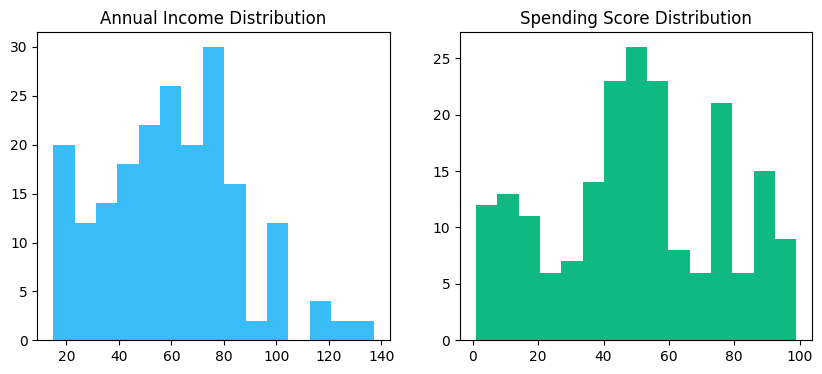

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(df['Annual Income (k$)'], bins=15, color='#38bdf8')
plt.title('Annual Income Distribution')

plt.subplot(1,2,2)
plt.hist(df['Spending Score (1-100)'], bins=15, color='#10b981')
plt.title('Spending Score Distribution')
plt.show()

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)' , 'Age']].values

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

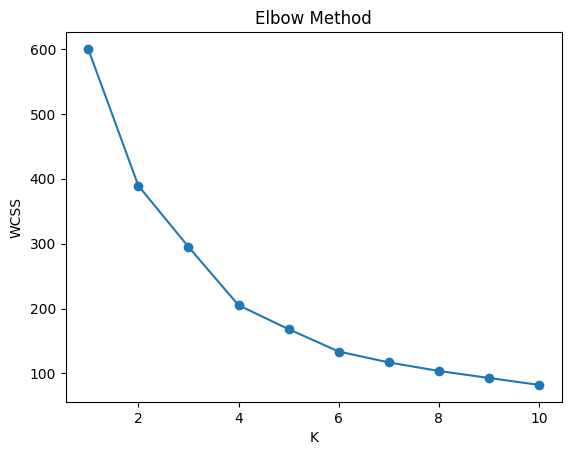

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

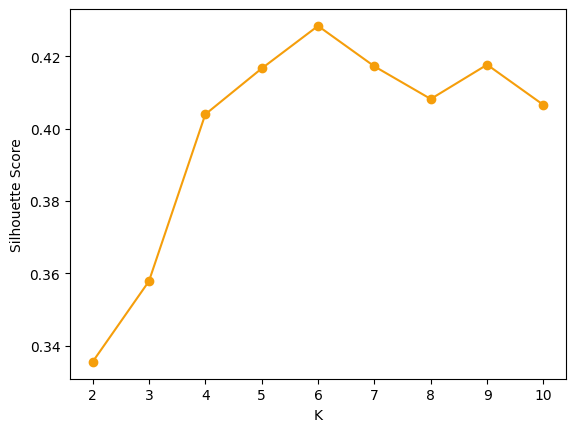

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2,11), sil_scores, marker='o', color='#f59e0b')
plt.xlabel('K'); plt.ylabel('Silhouette Score')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=6, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)-

KMeans(n_clusters=6, n_init=10, random_state=42)

In [ ]:
y_kmeans = kmeans.predict(X_scaled)

In [ ]:
df['Cluster'] = y_kmeans
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1.0,19,15,39,4
1,2,1.0,21,15,81,4
2,3,0.0,20,16,6,5
3,4,0.0,23,16,77,4
4,5,0.0,31,17,40,5


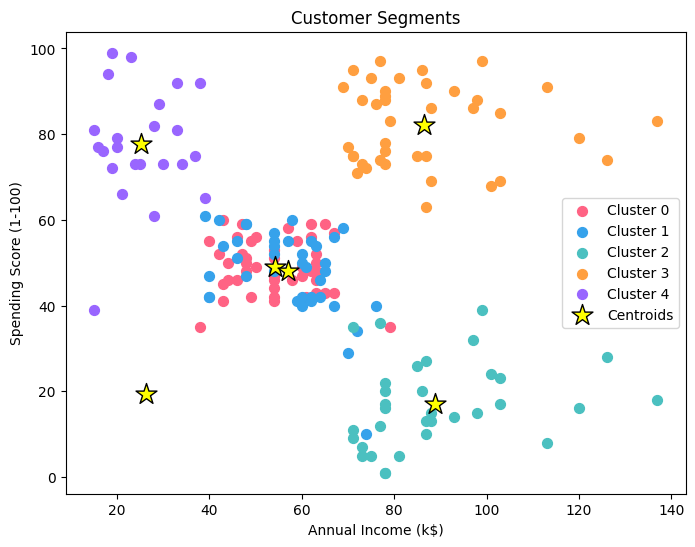

In [ ]:
plt.figure(figsize=(8,6))
colors = ['#ff6384','#36a2eb','#4bc0c0','#ff9f40','#9966ff']

for i in range(5):
    plt.scatter(X[y_kmeans==i, 0], X[y_kmeans==i, 1],
                s=50, c=colors[i], label=f'Cluster {i}')

# Centroids are in scaled space — inverse-transform to original units
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:,0], centroids_original[:,1],
            s=250, c='yellow', marker='*',
            edgecolor='black', label='Centroids')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.legend()
plt.show()